In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("chickwts.csv")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/brian/anaconda3/envs/cs82a/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/brian/anaconda3/envs/cs82a/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/brian/anaconda3/envs/cs82a/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io

AttributeError: _ARRAY_API not found

In [3]:
df.groupby("feed")["weight"].mean().sort_values()

feed
horsebean    160.200000
linseed      218.750000
soybean      246.428571
meatmeal     276.909091
casein       323.583333
sunflower    328.916667
Name: weight, dtype: float64

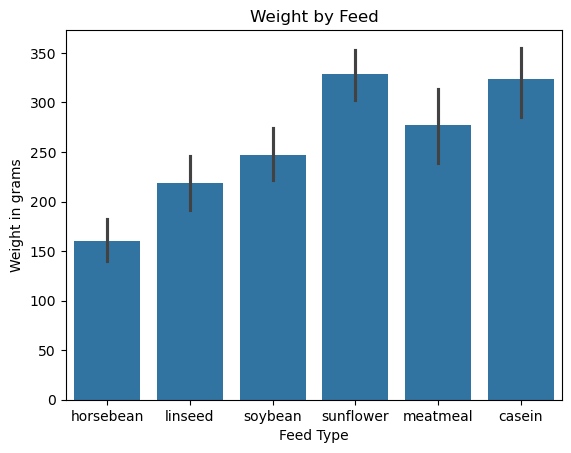

In [4]:
sns.barplot(data=df, x="feed", y="weight")
plt.title("Weight by Feed")
plt.xlabel("Feed Type")
plt.ylabel("Weight in grams")
plt.show()

The feed type with the highest weight is sunflower, closely followed by casein. While the lowest weight resides with horsebean. 

Text(0, 0.5, 'Count')

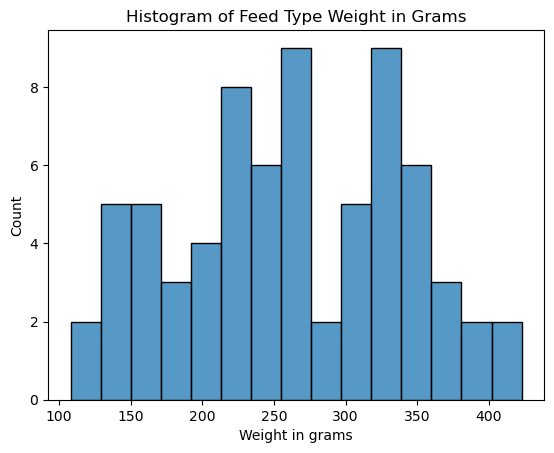

In [5]:
sns.histplot(data=df, x="weight", bins=15)
plt.title("Histogram of Feed Type Weight in Grams")
plt.xlabel("Weight in grams")
plt.ylabel("Count")

A roughly symmetrical distribution that is has its center around 260g. There does appear to be a dip around 280g that may require further investigation. 

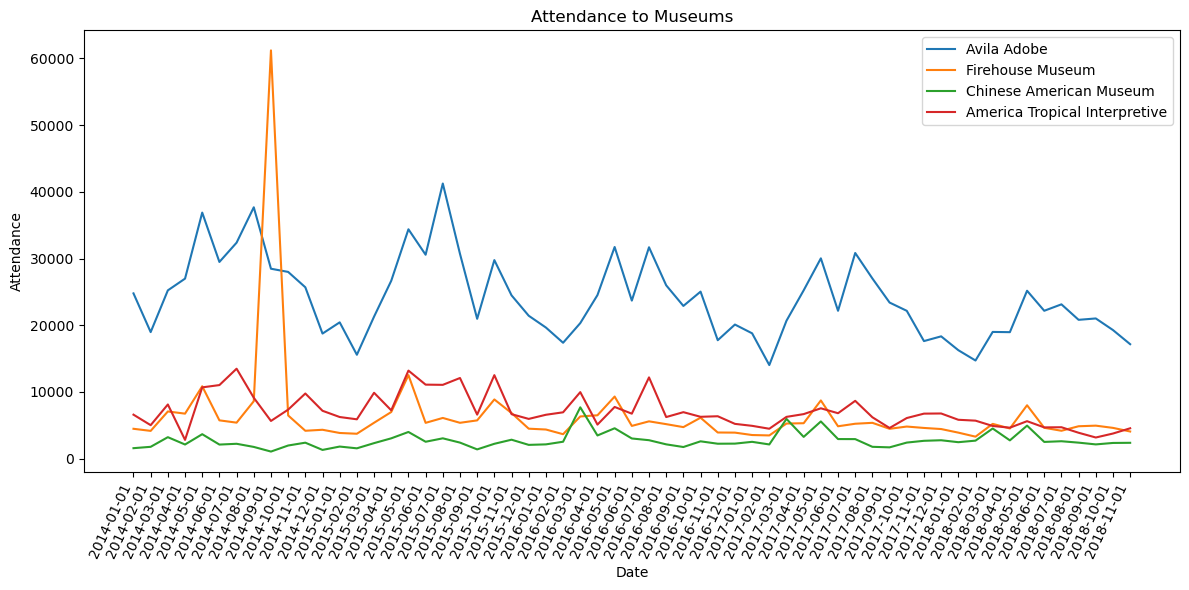

In [6]:
df = pd.read_csv("museum_visitors.csv")
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df, x="Date", y="Avila Adobe", label="Avila Adobe")
sns.lineplot(data=df, x="Date", y="Firehouse Museum", label="Firehouse Museum")
sns.lineplot(data=df, x="Date", y="Chinese American Museum", label="Chinese American Museum")
sns.lineplot(data=df, x="Date", y="America Tropical Interpretive Center", label="America Tropical Interpretive")
plt.title("Attendance to Museums")
plt.xlabel("Date")
plt.ylabel("Attendance")
fig.autofmt_xdate()
plt.xticks(rotation=65)
plt.tight_layout()


All museums appear to have a spike in attendance during the summer months. The Firehouse Museum appears to have an anomalous spike around Sept/Oct of 2014. Overall Avila Adobe has more visitors throughout the year, but the trend remains pretty consistent with the rest of the museums. 

Null Hypothesis: There is no difference between the weights of chicks that are sunflower-fed vs horsebean-fed. 

In actuality, from the data it appears that chicks that are sunflower-fed are considerable heavier than horsebean-fed chicks. 

In [7]:
from scipy.stats import ttest_ind
df = pd.read_csv("chickwts.csv")
a = df[df["feed"] == "sunflower"]["weight"]
b = df[df["feed"] == "horsebean"]["weight"]
ttest_ind(a, b)

TtestResult(statistic=np.float64(8.848346742516636), pvalue=np.float64(2.3743507676837164e-08), df=np.float64(20.0))

In conclusion, the effect size is 168.7g with a pvalue of 2.37. My verdict is that sunflower feed is more than twice as effective as the least effective feed (horsebean). Take a cautionary note however that the sample size that this data is collected from is quite small. With a larger sample size it is possible that this difference could decrease. 

The chart that I have chosen is the linechart of Museum Attendancy. For honesty I plotted every date so that I could make an accurate assesment of attendance. 

AI Usage:

Used AI to assist in formatting the lineplot so that the dates were readable on the x-axis. Asked multiple questions to Google like I normally would without AI and AI just happens to be the thing that now answers.

https://github.com/skeown13/cs82a-data-science-portfolio